In [ ]:
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path

n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc'
)
m = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00_50.nc'
)

In [88]:
n.links.carrier.unique()

array(['DC', 'co2 sequestered', 'OCGT', 'CCGT', 'H2 Electrolysis',
       'gas pipeline', 'gas pipeline new', 'battery charger',
       'battery discharger', 'Sabatier', 'SMR CC', 'SMR', 'BEV charger',
       'V2G', 'oil refining', 'land transport oil',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'biomass to liquid',
       'electrobiofuels', 'Haber-Bosch', 'ammonia cracker',
       'biomass-to-methanol', 'OCGT methanol',
       'heat100-200 industry solid biomass',
       'heat100-200 industry solid biomass CC',
       'heat100-200 industry industrial heat pump high temperature',
       'heat100-200 industry electric boiler steam',
       'heat200-500 industry solid biomass',
       'heat200-500 industry solid biomass CC',
       'heat200-500 industry hydrogen', 'heat

In [98]:
rural_heat = n.links.index[n.links.carrier == 'urban central gas CHP']

In [99]:
nd = n.links_t.p0[rural_heat]#.sum(axis=1).plot()
md = m.links_t.p0[rural_heat]#.sum(axis=1).plot()

In [100]:
diff = (nd - md)

In [102]:
diff.loc[:, diff.abs().sum().sort_values(ascending=False).index].head(2)

Link,IT0 1 urban central gas CHP,IT0 0 urban central gas CHP,DE0 5 urban central gas CHP,DE0 0 urban central gas CHP,CZ0 0 urban central gas CHP,DK0 0 urban central gas CHP,GB2 0 urban central gas CHP,GB2 1 urban central gas CHP,PL0 0 urban central gas CHP,NL0 0 urban central gas CHP,...,GB3 0 urban central gas CHP,XK0 0 urban central gas CHP,EE0 0 urban central gas CHP,ES6 0 urban central gas CHP,FI1 0 urban central gas CHP,FR0 1 urban central gas CHP,FR0 2 urban central gas CHP,FR0 0 urban central gas CHP,FR0 3 urban central gas CHP,NO1 0 urban central gas CHP
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.178112,1206.147759,0.086223,0.079486,0.010954,0.047452,-0.003548,-0.005054,0.103333,0.038113,...,-0.001556,-0.001412,0.005574,-0.000833,0.005123,-0.000292,-0.000497,-0.000565,-0.000532,-0.000648
2024-01-08,0.152974,0.047936,0.047499,0.046842,0.024627,0.018069,-117.475007,185.145538,0.098618,0.033571,...,-0.015870,-0.001080,-0.000415,0.001887,-0.001246,0.004484,0.003299,0.003022,0.002795,-0.000762


In [94]:
n.generators.carrier.unique()

array(['nuclear', 'offwind-float', 'offwind-ac', 'offwind-dc',
       'solar-hsat', 'onwind', 'solar', 'ror', 'gas', 'oil primary',
       'urban central heat vent', 'urban central solar thermal', 'biogas',
       'solid biomass', 'unsustainable biogas',
       'unsustainable solid biomass', 'unsustainable bioliquids', 'coal',
       'solar rooftop', 'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal',
       'co2-ets'], dtype=object)

In [95]:
nu = n.generators.index[n.generators.carrier == 'nuclear']

101795.19726441585

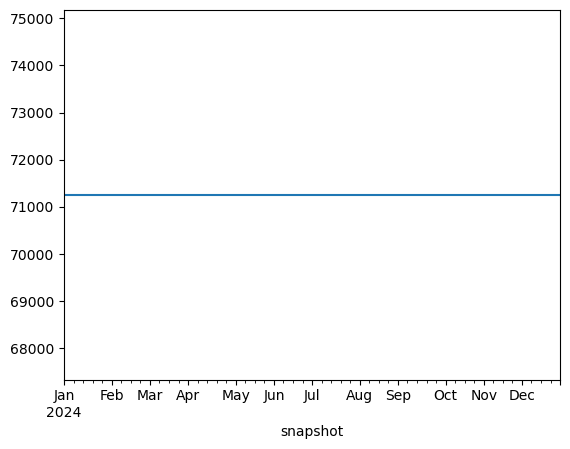

In [96]:
n.generators_t.p.loc[:, nu].sum(axis=1).plot()
m.generators_t.p.loc[:, nu].sum(axis=1).head()

n.generators.loc[nu, 'p_nom_opt'].sum()

In [97]:
m.generators_t.p.loc[:, nu].sum(axis=1).head()

snapshot
2024-01-01    71256.638085
2024-01-08    71256.638085
2024-01-15    71256.638085
2024-01-22    71256.638085
2024-01-29    71256.638085
dtype: float64

In [74]:
n.buses.loc[n.buses.carrier == 'AC'].index

Index(['AL0 0', 'AT0 0', 'BA0 0', 'BE0 0', 'BG0 0', 'CH0 0', 'CZ0 0', 'DE0 0',
       'DE0 1', 'DE0 2', 'DE0 3', 'DE0 4', 'DE0 5', 'DK0 0', 'DK1 0', 'EE0 0',
       'ES0 0', 'ES6 0', 'FI1 0', 'FR0 0', 'FR0 1', 'FR0 2', 'FR0 3', 'FR0 4',
       'FR5 0', 'GB2 0', 'GB2 1', 'GB3 0', 'GR0 0', 'HR0 0', 'HU0 0', 'IE3 0',
       'IT0 0', 'IT0 1', 'IT4 0', 'LT0 0', 'LU0 0', 'LV0 0', 'ME0 0', 'MK0 0',
       'NL0 0', 'NO1 0', 'PL0 0', 'PT0 0', 'RO0 0', 'RS0 0', 'SE1 0', 'SI0 0',
       'SK0 0', 'XK0 0'],
      dtype='object', name='Bus')

In [75]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry',
       'solid biomass for industry', 'gas for industry',
       'H2 for industry', 'industry methanol', 'naphtha for industry',
       'low-temperature heat for industry', 'industry electricity',
       'process emissions', 'NH3', 'coal for industry',
       'shipping methanol', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [104]:
n.buses_t.marginal_price.head()

Bus,AL0 0,AL0 0 EV battery,AL0 0 H2,AL0 0 agriculture machinery oil,AL0 0 battery,AL0 0 biogas,AL0 0 co2 sequestered,AL0 0 co2 stored,AL0 0 gas,AL0 0 gas for industry,...,XK0 0 non-sequestered HVC,XK0 0 process emissions,XK0 0 rural heat,XK0 0 shipping oil,XK0 0 solid biomass,XK0 0 solid biomass for industry,XK0 0 unsustainable bioliquids,XK0 0 urban central heat,XK0 0 urban decentral heat,co2 atmosphere
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01,82.028249,93.984214,65.123479,77.419329,0.0,62.444176,-36.077773,-36.087261,25.389630,0.0,...,-20.575712,0.0,52.819906,0.0,12.256243,12.266788,0.0,10.753850,53.588479,-79.990932
2024-01-08,72.089124,82.599104,66.638887,77.419329,0.0,62.444176,-35.976563,-35.986050,32.934236,0.0,...,-20.575712,0.0,138.591380,0.0,12.256244,12.266788,0.0,12.910678,127.763731,-79.990932
2024-01-15,68.439733,78.418880,64.092760,77.419329,0.0,62.444176,-35.920243,-35.929730,25.618585,0.0,...,-20.575712,0.0,53.547923,0.0,12.256243,12.266787,0.0,12.641370,52.523036,-79.990932
2024-01-22,67.647162,77.510946,63.027402,77.419329,0.0,62.444176,-35.845031,-35.854519,25.619117,0.0,...,-20.575712,0.0,44.303771,0.0,12.256243,12.266787,0.0,11.132061,41.690141,-79.990932
2024-01-29,75.156846,86.113102,62.405199,77.419329,0.0,62.444176,-35.787984,-35.797471,25.636383,0.0,...,-20.575712,0.0,45.077467,0.0,12.256243,12.266787,0.0,10.199461,40.760841,-79.990932


In [105]:
m.buses_t.marginal_price.head()

Bus,AL0 0,AL0 0 EV battery,AL0 0 H2,AL0 0 agriculture machinery oil,AL0 0 battery,AL0 0 biogas,AL0 0 co2 sequestered,AL0 0 co2 stored,AL0 0 gas,AL0 0 gas for industry,...,XK0 0 non-sequestered HVC,XK0 0 process emissions,XK0 0 rural heat,XK0 0 shipping oil,XK0 0 solid biomass,XK0 0 solid biomass for industry,XK0 0 unsustainable bioliquids,XK0 0 urban central heat,XK0 0 urban decentral heat,co2 atmosphere
snapshot,,,,,,,,,,,,,,,,,,,,,
2024-01-01,174.251050,199.646281,132.057674,77.446175,180.291492,59.935846,-50.893018,-50.911689,77.323767,0.0,...,-20.581751,0.0,55.879873,0.0,24.653305,24.667469,76.279001,7.160336,58.590777,-79.980483
2024-01-08,154.171355,176.644241,132.944801,77.446175,159.769753,59.905317,-50.789979,-50.808651,78.124410,0.0,...,-20.581751,0.0,75.651847,0.0,24.653303,24.667348,76.279002,8.681986,62.758265,-79.980483
2024-01-15,149.675306,171.495056,132.597123,77.446175,155.175174,59.906622,-50.779146,-50.797817,77.802986,0.0,...,-20.581751,0.0,54.994672,0.0,24.653304,24.667453,76.279002,8.565134,58.375324,-79.980483
2024-01-22,143.885430,164.861958,132.525840,77.446175,149.258721,59.862272,-50.737050,-50.755721,77.794777,0.0,...,-20.581751,0.0,55.202558,0.0,24.653332,24.667444,76.279001,9.434160,58.380475,-79.980482
2024-01-29,161.296493,184.805834,132.759688,77.446175,167.050878,59.863158,-50.921471,-50.940143,77.836967,0.0,...,-20.581751,0.0,56.697966,0.0,24.653334,24.667466,76.279001,8.353169,58.881700,-79.980482


In [112]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'heat100-200 industry',
       'heat200-500 industry', 'heat>500 industry',
       'solid biomass for industry', 'gas for industry',
       'H2 for industry', 'industry methanol', 'naphtha for industry',
       'low-temperature heat for industry', 'industry electricity',
       'process emissions', 'NH3', 'coal for industry',
       'shipping methanol', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [108]:
l = n.loads.index[n.loads.carrier == 'gas for industry']

In [111]:
n.loads.loc[l, 'p_set']

Load
AL0 0 gas for industry    0.0
AT0 0 gas for industry    0.0
BA0 0 gas for industry    0.0
BE0 0 gas for industry    0.0
BG0 0 gas for industry    0.0
CH0 0 gas for industry    0.0
CZ0 0 gas for industry    0.0
DE0 0 gas for industry    0.0
DE0 1 gas for industry    0.0
DE0 2 gas for industry    0.0
DE0 3 gas for industry    0.0
DE0 4 gas for industry    0.0
DE0 5 gas for industry    0.0
DK0 0 gas for industry    0.0
DK1 0 gas for industry    0.0
EE0 0 gas for industry    0.0
ES0 0 gas for industry    0.0
ES6 0 gas for industry    0.0
FI1 0 gas for industry    0.0
FR0 0 gas for industry    0.0
FR0 1 gas for industry    0.0
FR0 2 gas for industry    0.0
FR0 3 gas for industry    0.0
FR0 4 gas for industry    0.0
FR5 0 gas for industry    0.0
GB2 0 gas for industry    0.0
GB2 1 gas for industry    0.0
GB3 0 gas for industry    0.0
GR0 0 gas for industry    0.0
HR0 0 gas for industry    0.0
HU0 0 gas for industry    0.0
IE3 0 gas for industry    0.0
IT0 0 gas for industry    0.0
IT0 1

In [117]:
idx = pd.IndexSlice
n.statistics.energy_balance().loc[idx['Load']]

carrier                            bus_carrier               
H2 for industry                    Hydrogen Storage             -7.200000e+05
NH3                                NH3                          -8.730000e+07
agriculture electricity            low voltage                  -3.752588e+07
agriculture heat                   rural heat                   -2.148117e+08
agriculture machinery electric     low voltage                  -2.203878e+07
agriculture machinery oil          agriculture machinery oil    -5.142382e+07
coal for industry                  coal for industry            -4.541950e+08
electricity                        low voltage                  -1.536746e+09
heat100-200 industry               heat100-200 industry         -5.378000e+07
heat200-500 industry               heat200-500 industry         -5.360000e+06
heat>500 industry                  heat>500 industry            -1.718000e+07
industry electricity               low voltage                  -1.050200e+09
ke